🔍 根據最低 Validation Pcv Loss (0.008009)，找到最佳 Epoch 在: 541
✅ 圖片已成功儲存至: results_figure\loss_curve_replot_Pcv_best.svg


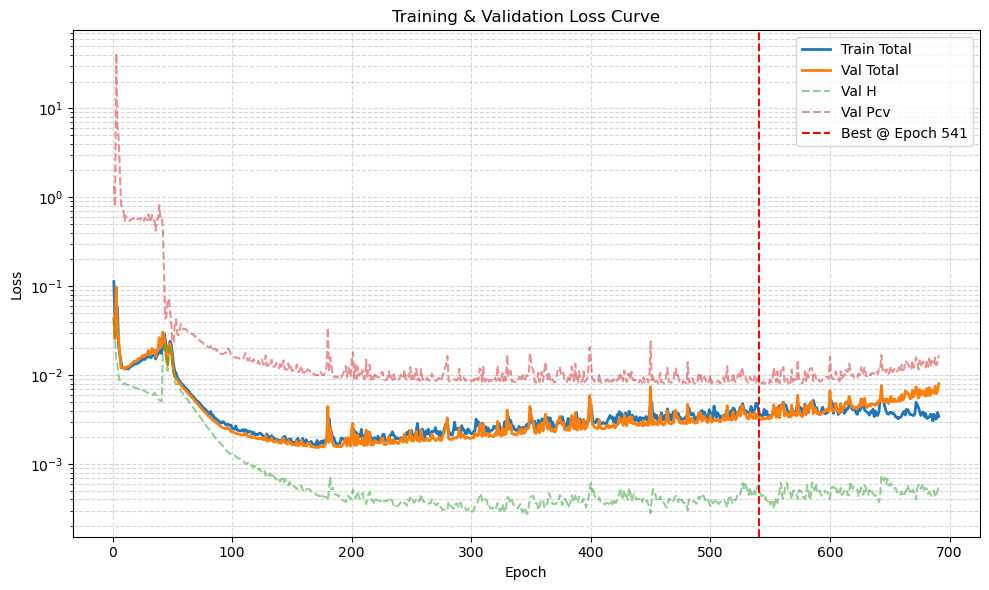

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 設定區 ---
# 你的 JSON 檔案名稱
json_file_path = 'training_history.json'
# 圖片儲存的資料夾
result_dir = 'results_figure'
# 是否要顯示圖片
save_figure = True

# --- 主程式區 ---
# 建立儲存圖片的資料夾
os.makedirs(result_dir, exist_ok=True)

# 讀取 JSON 檔案並轉換成 pandas DataFrame
try:
    with open(json_file_path, 'r', encoding='utf-8') as f:
        history_data = json.load(f)
    history = pd.DataFrame(history_data)
except FileNotFoundError:
    print(f"❌ 錯誤：找不到 '{json_file_path}' 檔案，請確認檔案名稱和路徑是否正確。")
    exit()

# === ✨修改處✨ ===
# 根據 Validation Pcv Loss (loss_Pcv) 找出最佳模型的 epoch
best_epoch_row = history.loc[history['loss_Pcv'].idxmin()]
best_epoch = int(best_epoch_row['epoch'])
print(
    f"🔍 根據最低 Validation Pcv Loss ({best_epoch_row['loss_Pcv']:.6f})，找到最佳 Epoch 在: {best_epoch}"
)

# 開始繪圖
plt.figure(figsize=(10, 6))

# --- ① 繪製 Train / Val Total loss ---
plt.plot(history['epoch'],
         history['train_loss'],
         label="Train Total",
         linewidth=2)
plt.plot(history['epoch'], history['val_loss'], label="Val Total", linewidth=2)

# --- ② 另外畫 Val H-loss、Val Pcv-loss (透明度低一點) ---
plt.plot(history['epoch'],
         history['loss_H'],
         label="Val H",
         alpha=0.5,
         ls="--")
plt.plot(history['epoch'],
         history['loss_Pcv'],
         label="Val Pcv",
         alpha=0.5,
         ls="--")

# --- ③ 設定座標軸與標題 ---
plt.yscale('log')
plt.title("Training & Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, which="both", ls="--", alpha=0.5)

# --- ④ 標出最佳模型 epoch 的垂直線 ---
plt.axvline(best_epoch, ls="--", c="r", label=f"Best @ Epoch {best_epoch}")

# 顯示圖例
plt.legend()

# --- ⑤ 儲存圖片 ---
fig_loss_path = os.path.join(result_dir, "loss_curve_replot_Pcv_best.svg")
plt.tight_layout()
plt.savefig(fig_loss_path)
print(f"✅ 圖片已成功儲存至: {fig_loss_path}")

if save_figure:
    plt.show()
else:
    plt.close()